In [2]:
# 1. Bring the entire folder structure into Colab's temporary server
!git clone https://github.com/schmittms/physical_bottleneck.git

# 2. Change our current working directory to be inside that folder
%cd physical_bottleneck

Cloning into 'physical_bottleneck'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 23 (delta 6), reused 23 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 2.37 MiB | 12.37 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/physical_bottleneck


In [3]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

# Directory where all the data is stored
import os
drive_save_dir = '/content/drive/MyDrive/processed/TractionData_All_16kpa/checkpoints'

Mounted at /content/drive


In [4]:
# 1. Install the stable FEniCS backend
!wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"

# 2. Install dolfin-adjoint
!pip install git+https://github.com/dolfin-adjoint/pyadjoint.git@2019.1.0

# 3. Install missing math libs
!pip install pysindy pytorch-lightning

--2026-03-31 19:32:33--  https://fem-on-colab.github.io/releases/fenics-install-release-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4180 (4.1K) [application/x-sh]
Saving to: ‘/tmp/fenics-install.sh’

/tmp/fenics-install 100%[===================>]   4.08K  --.-KB/s    in 0s      

2026-03-31 19:32:33 (50.8 MB/s) - ‘/tmp/fenics-install.sh’ saved [4180/4180]

+ INSTALL_PREFIX=/usr/local
++ echo /usr/local
++ awk -F/ '{print NF-1}'
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FENICS_INSTALLED=/usr/local/share/fem-on-colab/fenics.installed
+ [[ ! -f /usr/local/share/fem-on-colab/fenics.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/7e396ce3/releases/pybi

In [5]:
!apt-get update && apt-get install -y fenics && pip install fenics-adjoint

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,955 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,173 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,954 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,620 kB]
Get:14 http://security.ubuntu

In [6]:
!pip install pysindy pytorch-lightning

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps
import pytorch_lightning as pl
import torch
from scipy.ndimage import gaussian_filter
from sklearn.metrics import mean_squared_error
import os
import pandas as pd
import skimage.measure as measure
import scipy
from skimage.morphology import disk
import torchvision

import torch.nn as nn
# --- THE CRITICAL BRIDGE ---
import sys
import ufl_legacy
sys.modules['ufl'] = ufl_legacy


import ufl
import dolfin as dlf
import dolfin_adjoint as d_ad
import pyadjoint as pyad

from torchvision import transforms

import warnings
import time
warnings.filterwarnings('ignore')
from tqdm.autonotebook import tqdm


from utils.nn import ConvNextCell, DownsampleLayer
from utils.PB_utils import Dataset, PB_model
import utils.proc as proc

#from process_mask_generate_mesh

# %load_ext autoreload
# %autoreload 2
%matplotlib inline

pl.seed_everything(1)
np.random.seed(1)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1


# Dataset

In [8]:
##### Data args ######
data_root="/content/drive/MyDrive/Box_Massive_Download/processed/TractionData_All_16kpa"
train_cells="11_cell_0"

##### Training args ######
n_epochs=101
pde_epochs=101
batch_size=16

# Preparing the entire dataset

In [9]:
# import os
# import shutil
# import glob

# from google.colab import drive
# drive.mount('/content/drive',force_remount=True)

# # Your specific paths based on the error message
# SOURCE_DIR = "/content/drive/MyDrive/Box_Massive_Download/processed/TractionData_All_16kpa/"
# DEST_DIR = "/content/drive/MyDrive/Box_Massive_Download/entire_dataset/"

# os.makedirs(DEST_DIR, exist_ok=True)
# print("Gathering files and RESUMING flat dataset prep...\n")

# all_files = glob.glob(os.path.join(SOURCE_DIR, "**", "*.*"), recursive=True)
# success_count = 0
# skip_count = 0

# for file_path in all_files:
#     ext = os.path.splitext(file_path)[1]

#     if ext not in ['.npy', '.xml']:
#         continue

#     folder_name = os.path.basename(os.path.dirname(file_path))
#     original_name = os.path.basename(file_path)
#     name_without_ext = os.path.splitext(original_name)[0]
#     frame_number = name_without_ext.split('_')[-1]

#     new_filename = f"{folder_name}-{frame_number}{ext}"
#     new_file_path = os.path.join(DEST_DIR, new_filename)

#     # --- RESUME FEATURE ---
#     # If the file already successfully copied before the crash, skip it!
#     if os.path.exists(new_file_path):
#         skip_count += 1
#         continue

#     # Copy the remaining files
#     try:
#         shutil.copy2(file_path, new_file_path)
#         success_count += 1
#     except Exception as e:
#         print(f"\nColab Drive connection dropped again on {new_filename}.")
#         print(f"Error: {e}")
#         break

# print(f"\nDone! Safely copied {success_count} NEW files.")
# print(f"Skipped {skip_count} files that were already completed before the crash.")

In [10]:
import pyadjoint as pyad
from pyadjoint.reduced_functional_numpy import ReducedFunctionalNumPy

# THE PATCH: Attach the hidden tool to the main module so the author's code can find it
pyad.ReducedFunctionalNumPy = ReducedFunctionalNumPy

print("Successfully patched pyadjoint!")

Successfully patched pyadjoint!


In [11]:
DEST_DIR = "/content/drive/MyDrive/Box_Massive_Download/entire_dataset/"
dataset = Dataset(root=DEST_DIR,
                  cells_to_include=['11_cell_0'],
                  frames_to_include = np.arange(0,120,3),#[0,39,79,119], # np.arange(2)
                  n_include=16, indices=16)

print("DF cells:", dataset.df.cell.unique(), "\t DF len:", len(dataset.df))

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_4f750817ecc896f3bedcb4ff8c9f3352153b1b38

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00454497 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.279298 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representatio

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_3801828c0f66b7190a7fd5819465b3d5b34b9149

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00216532 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.0097158 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representati

Calling FFC just-in-time (JIT) compiler, this may take some time.


...

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_dd9baaea625355081b5519d8763464dc23cc7161

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00394201 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.0200827 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representati

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling coordinate_mapping ffc_coordinate_mapping_84d495a78101e005b3c3473583b2e920e2771158

INFO:FFC:Compiler stage 1: Analyzing coordinate_mapping(s)
INFO:FFC:-------------------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00659585 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 0 elements
INFO:FFC:  Computing representation of 0 dofmaps
INFO:FFC:  Computing representation of 1 coordinate mappings
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.0147469 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representation
INFO:FFC:--------------------------------------------------------
INFO

DF cells: [np.str_('11_cell_0')] 	 DF len: 40


In [12]:
##### Model Args ######
N_layers=5
LR=0.00001
PDE_LR=0.001
gamma=0.995

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')


# Seed before making model for reproducibility
torch.manual_seed(0)
np.random.seed(0)

model = PB_model(
                 kernel_size=9,
                 LR=LR,
                 N_layers=5,
                 N_latent_layers=5,
                 hidden_channels=32,
                 gamma=0.995,
                 regularization=None,
                 batch_size=16,
                 logdir=None)

model.to(device);

In [14]:
### PRETRAIN ##
sig_init = 1e-1
a_init = 1e-1
d_ad.set_working_tape(d_ad.Tape())

# 1. Define where to save the checkpoint on your Drive
CHECKPOINT_PATH = "/content/drive/MyDrive/PB_pretrain_checkpoint.pth"

# 2. Initialize tracking variables
start_epoch = 0
loss_history = []

# 3. Resume Logic: Check if a previous save exists
if os.path.exists(CHECKPOINT_PATH):
    print(f"Found existing checkpoint at {CHECKPOINT_PATH}!")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    checkpoint = torch.load(CHECKPOINT_PATH, weights_only=False, map_location=device)

    # Restore the model, optimizer, scheduler, and history
    model.load_state_dict(checkpoint['model_state_dict'])
    model.opt.load_state_dict(checkpoint['optimizer_state_dict'])
    model.sch.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    loss_history = checkpoint['loss_history']

    print(f"Resuming pretraining from Epoch {start_epoch}...")
else:
    print("No checkpoint found. Starting pretraining from scratch...")

# 4. The Training Loop
t0 = time.time()
# Adjust tqdm to reflect the remaining epochs
pbar = tqdm(total=n_epochs, initial=start_epoch)

for i in range(start_epoch, n_epochs):
    for s in range(len(dataset)):
        m = i*len(dataset) + s

        sample = dataset[s]
        sample['zyx'] = sample['zyx'].to(device)
        sample['Y_init'] = sample['Y_init'].to(device)
        sample['mask_bool'] = sample['mask_bool'].to(device)

        loss, y_im, sig_a, alpha = model.pretrain(sample['zyx'], 1e2*sample['Y_init'], sig_init, a_init, mask=sample['mask_bool'])

        if torch.isnan(loss):
            raise ValueError(f"Nans encountered, iter {m}")

        loss_history.append(loss.detach().cpu().numpy())

    pbar.update(1)

    # 5. Save Logic: Save a checkpoint at the end of every epoch
    checkpoint = {
        'epoch': i,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': model.opt.state_dict(),
        'scheduler_state_dict': model.sch.state_dict(),
        'loss_history': loss_history
    }
    torch.save(checkpoint, CHECKPOINT_PATH)

print(f"Pretraining complete in {time.time() - t0:.2f} seconds.")

Found existing checkpoint at /content/drive/MyDrive/PB_pretrain_checkpoint.pth!
Resuming pretraining from Epoch 101...


100%|##########| 101/101 [00:00<?, ?it/s]

Pretraining complete in 0.04 seconds.


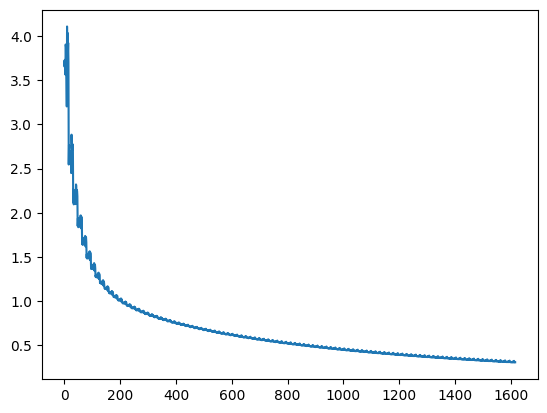

In [15]:
plt.plot(loss_history)

In [17]:
import os

# 1. Define a completely unique checkpoint name for the physics exam
STAGE2_CHECKPOINT = "/content/drive/MyDrive/PB_physics_stage2_checkpoint.pth"

start_epoch = 0

# 2. Resume Logic
if os.path.exists(STAGE2_CHECKPOINT):
    print(f"Found existing physics checkpoint at {STAGE2_CHECKPOINT}!")
    checkpoint = torch.load(STAGE2_CHECKPOINT, weights_only=False, map_location=torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

    # Restore the model, optimizer, and scheduler
    model.load_state_dict(checkpoint['model_state_dict'])
    model.opt.load_state_dict(checkpoint['optimizer_state_dict'])
    if 'scheduler_state_dict' in checkpoint and checkpoint['scheduler_state_dict'] is not None:
        model.sch.load_state_dict(checkpoint['scheduler_state_dict'])

    start_epoch = checkpoint['epoch'] + 1
    print(f"Resuming physics training from Epoch {start_epoch}...")

else:
    print("No checkpoint found. Starting Stage 2 from scratch...")
    # ONLY reset the learning rate if we are starting from 0.
    # If we are resuming, we want to keep the carefully decayed learning rate!
    for g in range(len(model.opt.param_groups)):
        model.opt.param_groups[g]['lr'] = PDE_LR


# 3. The Training Loop
# Set initial=start_epoch so the progress bar visually picks up where it left off
pbar = tqdm(total=n_epochs, initial=start_epoch)

for i in range(start_epoch, n_epochs):
    for s in range(len(dataset)):
        m = i*len(dataset) + s
        sample = dataset[s]

        # Ensure the tensor is on the correct device
        sample['zyx'] = sample['zyx'].to(device)

        constants, y_im, y_mesh_vals, J, _ = model.step(
            sample['zyx'],
            sample['Jhat'],
            len(sample['control_arr']),
            sample['Y_FctSpace']
        )

        #model.logger.add_scalar('PDE_Loss', J, global_step=m)
        #model.logger.add_scalar('PDE_LR', model.opt.param_groups[0]['lr'], global_step=m)

    # Update progress bar once per EPOCH, not once per image
    pbar.update(1)

    # 4. Save Logic: Save checkpoint at the end of every epoch
    checkpoint_data = {
        'epoch': i,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': model.opt.state_dict(),
        'scheduler_state_dict': model.sch.state_dict() if hasattr(model, 'sch') else None
    }
    torch.save(checkpoint_data, STAGE2_CHECKPOINT)

print("Stage 2 Physics training is complete!")

Found existing physics checkpoint at /content/drive/MyDrive/PB_physics_stage2_checkpoint.pth!
Resuming physics training from Epoch 35...


 35%|###4      | 35/101 [00:00<?, ?it/s]

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_f84dd1967a15d084db712d4526efa3e937dcaae9

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      2
  Arguments:                 '(v_0, v_1)'
  Number of coefficients:    2
  Coefficients:              '[f_1208, f_1212]'
  Unique elements:           'Vector<2 x CG1(?,?)>, CG1(?,?), R0(?,?)'
  Unique sub elements:       'Vector<2 x CG1(?,?)>, CG1(?,?), R0(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 3
INFO:FFC:  quadrature_degree: 3
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0299451 seconds.

INFO:FFC:Co

Calling FFC just-in-time (JIT) compiler, this may take some time.


...

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_aeeaf2694543445e0bdc4cb919786f8c6871f863

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    2
  Coefficients:              '[f_1213, f_1457]'
  Unique elements:           'R0(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:       'R0(?,?), Vector<2 x CG1(?,?)>, CG1(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 0
INFO:FFC:  quadrature_degree: 0
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0250266 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:------------

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_2851f601281774af793b35a338fe4ec7c6b7aef4

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    2
  Coefficients:              '[f_1213, f_1457]'
  Unique elements:           'CG1(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:       'CG1(?,?), Vector<2 x CG1(?,?)>'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 3
INFO:FFC:  quadrature_degree: 3
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0240512 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:--------------------

AssertionError: Torch not compiled with CUDA enabled

In [18]:
# Check where CUDA is hardcoded in your model
import inspect
print(inspect.getsource(model.step))

    def step(self, x, Jhat, len_control_arr, Y_FctSpace):
        self.batch_counter += 1
        if self.batch_counter == 1: self.opt.zero_grad()
        
        y_im, y_mesh_vals, constants = self.forward(x, Y_FctSpace)
        
        assert len(y_mesh_vals) + len(constants.squeeze()) == len_control_arr
        
        control_arr = np.zeros(len_control_arr)
        
        control_arr[:len(y_mesh_vals)] = y_mesh_vals.detach().cpu().numpy()
        control_arr[-2] = constants[0] # sig
        control_arr[-1] = constants[1] # alpha

        J = Jhat(control_arr) # Tape gets two z
        dJdy = Jhat.derivative(control_arr, forget=True, project=False)

        y_mesh_vals.backward(gradient=torch.tensor(dJdy[:-2], device=torch.device('cuda:0'))/self.batch_size) #+ self.y_regularization*y_mesh_vals.abs())
        constants[0].backward(gradient=torch.tensor(dJdy[-2], device=torch.device('cuda:0'))/self.batch_size, retain_graph=True)
        constants[1].backward(gradient=torch.tensor

In [ ]:
# For plotting F
mesh = sample['Y_FctSpace'].mesh()
sigma_a = d_ad.Constant(constants[0].detach().numpy(), name = "sigma")
alpha = d_ad.Constant(constants[1].detach().numpy(), name = "alpha")

#### Generate Y, F fields on mesh ####
Y_mesh = d_ad.Function(sample['Y_FctSpace'])
F_mesh = proc.vector_img_to_mesh(sample['F'].squeeze().detach().numpy(), dlf.VectorFunctionSpace(mesh, 'CG', 1, dim=2))
Y_mesh.vector()[:] = y_mesh_vals.detach().numpy()
u,_,_ = sample['pde_forward'](Y_mesh, sigma_a, alpha, mesh)

    #model.logger.add_scalar('Sig', constants[0].detach().cpu().numpy(), global_step=i+args.epochs)
    #model.logger.add_scalar('Alpha', constants[1].detach().cpu().numpy(), global_step=i+args.epochs)
    #model.plot_Y(i+args.epochs, sample['zyx'].detach().cpu().numpy().squeeze(), y_im.detach().cpu().numpy().squeeze())
    #model.plot_F(i+args.epochs, F_mesh, Y_mesh, u)

    #torch.save(model.state_dict(), os.path.join(args.logdir, './model.pt'))

# Evaluate LR effect on pretraining

In [ ]:
loss_all = []

gpu_train = True

pbar_LRs = tqdm(total=6, desc='')
for LR in [1e-3]:
    for N_layers in [10]:
        pbar_LRs.set_description(f'LR {LR:0.2e} N_layers {N_layers}')
        torch.manual_seed(0)
        np.random.seed(0)

        model = PDEModel2D(
                         kernel_size=15,
                         LR=LR,
                         N_layers=N_layers,
                         N_latent_layers=N_layers,
                         hidden_channels=32,
                         gamma=0.995,
                         regularization=None,
                         batch_size=len(dataset.red_dataset),
                         exp=False)

        if gpu_train: model.to(torch.device('cuda:0'))


        sig_init = 1e-1
        a_init = 1e-1
        d_ad.set_working_tape(d_ad.Tape())
        #d_ad.get_working_tape().get_blocks()[:] = []
        print(len(d_ad.get_working_tape().get_blocks()))

        pretrain_loss = []
        t0 = time.time()
        epochs = 301
        pbar_outer = tqdm(total=epochs, desc='')
        pbar_inner = tqdm(total=len(dataset), desc='')
        for i in range(epochs):
            pbar_outer.update(1) # update progress bar for each iteration step
            pbar_inner.reset()
            for s in range(len(dataset)):
                pbar_inner.set_description(f'Sample {s}')
                pbar_inner.update(1) # update progress bar for each iteration step
                m = i*len(dataset) + s

                sample = dataset[s]

                if gpu_train: sample['zyx'] = sample['zyx'].to(torch.device('cuda:0'))
                if gpu_train: sample['Y_init'] = sample['Y_init'].to(torch.device('cuda:0'))
                if gpu_train: sample['mask_bool'] = sample['mask_bool'].to(torch.device('cuda:0'))


                pretrain_loss.append( [x.detach().cpu().numpy() for x in model.pretrain(sample['zyx'], 1e2*sample['Y_init'],
                                                                                  sig_init, a_init, mask=sample['mask_bool'])][0])
                if np.any(np.isnan(pretrain_loss)):
                    raise ValueError(f"Nans encountered, iter {m}\t{pretrain_loss[-1]}")
            pbar_outer.set_description(f'Epoch {i}, loss {pretrain_loss[-1]:0.2e}')

        loss_all.append({'N_layers': N_layers, 'LR': LR, 'loss': pretrain_loss})
        pbar_LRs.update(1)


In [ ]:
y_im = model.forward(sample['zyx'], None)[0].detach().cpu().numpy().squeeze()

In [ ]:
plt.imshow(np.log(y_im), vmax=1e-3, vmin=-20)

In [ ]:
plt.semilogy(pretrain_loss)

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(8,5),dpi=200)

nlayers_list = np.unique([x['N_layers'] for x in loss_all])
loglr = np.unique([x['LR'] for x in loss_all])

markers = {item: f'${item}$' for item in nlayers_list}
colors = {l: np.log10(l)/np.min(np.log10(loglr)) for l in loglr}


print(colors.keys())
freq = 10
ax.set_title(f'Batch size: {model.batch_size}')
for loss_ in loss_all:
    L = loss_['loss']
    clr = colors[loss_['LR']]
    mrkr = markers[loss_['N_layers']]
    L_avg = np.mean( np.asarray(L).reshape(-1, model.batch_size), axis=1)
    #ax.semilogy(np.arange(len(L))/model.batch_size, L, color=plt.get_cmap('Blues')( lr/np.min(loglr) ), label=lr )
    ax.semilogy(L_avg, color=plt.get_cmap('Blues')(clr))
    ax.semilogy(np.arange(len(L_avg))[::freq], L_avg[::freq], color=plt.get_cmap('Blues')(clr), marker=mrkr)


for m in markers:
    ax.plot([],[],color='k', marker=markers[m], label=m)


for c in colors:
    ax.plot([],[],color=plt.get_cmap('Blues')(colors[c]), label=c)


ax.legend(title='Log LR', frameon=False, ncol=2)
ax.set_ylim(None, 1e-2)
#ax.set_xlim(150, None)
ax.set_ylabel("Pretrain Loss")
ax.set_xlabel("Epoch")

# Model

In [ ]:
for i in range(len(model.opt.param_groups)):
    print(i, model.opt.param_groups[i]['name'])

In [ ]:
model = PDEModel2D(
             kernel_size=15,
             LR=1e-3,
             N_layers=10,
             N_latent_layers=10,
             hidden_channels=32,
             gamma=0.995,
             regularization=None,
             batch_size=len(dataset.red_dataset),
             exp=False)


In [ ]:
#print(model.opt)
#print(len(model.opt))
#torch.save(model.state_dict(), './cell_1_model_state_dict.pt')

model.load_state_dict(torch.load('./cell_1_model_state_dict.pt'))


In [ ]:
state_dict_saved = model.state_dict().copy()

# LR effect on PDE training

In [ ]:
pde_loss_all = []

pbar_LRs = tqdm(total=2, desc='')
for LR in [1e-3]:#, 1e-5, 1e-8]:
    for N_layers in [10]:
        pbar_LRs.set_description(f'LR {LR:0.2e} N_layers {N_layers}')
        torch.manual_seed(0)
        np.random.seed(0)

        model = PDEModel2D(
                         kernel_size=15,
                         LR=LR,
                         N_layers=N_layers,
                         N_latent_layers=N_layers,
                         hidden_channels=32,
                         gamma=0.995,
                         regularization=None,
                         batch_size=len(dataset.red_dataset),
                         exp=False)

        model.load_state_dict(state_dict_saved)

        model.opt.param_groups[0]['lr'] = LR
        model.opt.param_groups[1]['lr'] = LR # coefs
        model.opt.param_groups[2]['lr'] = LR # const_net

        loss = []

        t0 = time.time()

        pde_epochs = 101
        pde_pbar_outer = tqdm(total=pde_epochs, desc='')
        pde_pbar_inner = tqdm(total=len(dataset), desc='')

        for i in range(pde_epochs):
            pde_pbar_outer.set_description(f'Epoch {i}')
            pde_pbar_outer.update(1) # update progress bar for each iteration step
            pde_pbar_inner.reset()
            for s in range(len(dataset)):
                m = i*len(dataset) + s
                sample = dataset[s]

                sample['zyx'] = sample['zyx'].to(torch.device('cpu'))
                sample['Y_init'] = sample['Y_init'].to(torch.device('cpu'))
                sample['mask_bool'] = sample['mask_bool'].to(torch.device('cpu'))


                _, _, _, J, _ = model.step(sample['zyx'], sample['Jhat'], len(sample['control_arr']), sample['Y_FctSpace'])

                loss.append(J)

                pde_pbar_inner.set_description(f'Sample {s}, Loss {J:0.2f}')
                pde_pbar_inner.update(1) # update progress bar for each iteration step

        pde_loss_all.append({'kernel LR': kernel_LR, 'LR': LR, 'loss': loss})


In [ ]:
fig,ax=plt.subplots(1,1,figsize=(8,5),dpi=200)

logkernellr = np.unique([x['kernel LR'] for x in pde_loss_all])
loglr = np.unique([x['LR'] for x in pde_loss_all])

markers = {k: item for k, item in zip(logkernellr, np.arange(4,7))}
colors = {l: np.log10(l)/np.min(np.log10(loglr)) for l in loglr}

print(colors.keys())
freq = 1
ax.set_title(f'Batch size: {model.batch_size}')
for loss_ in pde_loss_all:
    L = loss_['loss']
    clr = colors[loss_['LR']]
    mrkr = markers[loss_['kernel LR']]
    L_avg = np.mean( np.asarray(L).reshape(-1, model.batch_size), axis=1)
    ax.semilogy(np.arange(len(L))/model.batch_size, L )#, color=plt.get_cmap('Blues')( lr/np.min(loglr) ), label=lr )
    ax.semilogy(L_avg, color=plt.get_cmap('Blues')(clr))
    ax.semilogy(np.arange(len(L_avg))[::freq], L_avg[::freq], color=plt.get_cmap('Blues')(clr), marker=mrkr, ls='none')


for m in markers:
    ax.plot([],[],color='k', marker=markers[m], label=m)
for c in colors:
    ax.plot([],[],color=plt.get_cmap('Blues')(colors[c]), label=c)


ax.legend(title='Log LR', frameon=True, ncol=2)
ax.set_ylim(None, 3e4)
#ax.set_xlim(150, None)
ax.set_ylabel("PDE train Loss")
ax.set_xlabel("Epoch")

In [ ]:
plt.plot(loss)

# Plot

In [ ]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(8,4),dpi=200)

gs = GridSpec(2, 12, figure=fig)
ax = {}
ax['zyx'] = fig.add_subplot(gs[0, 0:3])
ax['yinit'] = fig.add_subplot(gs[0, 3:6])

ax['ypre'] = fig.add_subplot(gs[0, 6:9])
ax['yfinal'] = fig.add_subplot(gs[0, 9:])
ax['pre_loss'] = fig.add_subplot(gs[1, 0:4])
ax['pde_loss'] = fig.add_subplot(gs[1, 4:8])
ax['consts'] = fig.add_subplot(gs[1, 8:])

for key in ['zyx','yinit','ypre','yfinal']:
    ax[key].axis('off')

sample = dataset[1]
with torch.no_grad():
    y_im, _, _ = model.forward(sample['zyx'],None)

ax['zyx'].imshow(sample['zyx'].squeeze().detach().cpu().numpy(), cmap='gray', origin='lower', vmin=0, vmax=1)

vmax = 1e-3#1e-4#None #Y_init_scale
vmin= None
im_init = ax['yinit'].imshow(sample['Y_init'].squeeze().detach().cpu().numpy(), cmap='Greens', origin='lower', vmin=vmin, vmax=vmax)
#im_pre = ax['ypre'].imshow(y_ims[0].squeeze().detach().numpy(), cmap='Greens', origin='lower', vmin=vmin, vmax=vmax)
#y_post_plot = y_ims[-1].squeeze().detach().numpy()
y_post_plot = y_im.squeeze().detach().cpu().numpy()
print(y_im.min())
print(y_im.max())
#y_post_plot[sample['mask_bool'].squeeze().detach().numpy()==0] = 0
im_post = ax['yfinal'].imshow(y_post_plot, cmap='Greens', origin='lower', vmin=vmin, vmax=vmax)#, vmin=0., vmax=0.00115)

cax_init = ax['yinit'].inset_axes([0.02, 0.05, 0.03, 0.3])
cax_pre = ax['ypre'].inset_axes([0.02, 0.05, 0.03, 0.3])
cax_final = ax['yfinal'].inset_axes([0.02, 0.05, 0.03, 0.3])


cb_init = fig.colorbar(im_init, cax_init)
#cb_pre = fig.colorbar(im_pre, cax_pre)
cb_final = fig.colorbar(im_post, cax_final)

#cb_init.ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useOffset=True)
for cb in [cb_init, cb_pre, cb_final]:
    cb.formatter.set_powerlimits((0, 0))
    cb.ax.yaxis.set_offset_position('left')
    cb.ax.yaxis.offsetText.set_fontsize(8)
    #cb.ax.yaxis.offsetText.set_text('$10^{-3}$')
    #useMathText


ax['pre_loss'].semilogy(np.asarray(pretrain_loss)[:,0])
ax['pde_loss'].semilogy(loss)
ax['consts'].plot(constant_evol[:,0], label='$\\sigma_a$', color='b')
ax2 = ax['consts'].twinx()
ax['consts'].plot([],[], label='$\\alpha$', color='gray')
ax2.plot(constant_evol[:,1], label='$\\alpha$', color='gray')

ax['consts'].legend(frameon=False, loc='lower right')
ax['consts'].tick_params(colors='blue', which='both', axis='y')  # 'both' refers to minor and major axes
ax2.tick_params(colors='gray', which='both', axis='y')  # 'both' refers to minor and major axes



for key in ['pre_loss','pde_loss','consts']:
    ax[key].tick_params(axis='both', which='both', direction='in')

#ax['pde_loss'].set_yticklabels([])
#ax['pde_loss'].set_ylim(None, 1e4)
ax['zyx'].set_title('Zyxin')
ax['yinit'].set_title('$Y_{init}$ ($\\propto |F|$)')
ax['ypre'].set_title('$Y$ after \npretraining')
ax['yfinal'].set_title('$Y$ after\nPDE training')
ax['pde_loss'].set_title('PDE training loss')
ax['consts'].set_title('Constants')

fig.set_facecolor('w')

In [ ]:
print(np.sum(sample['Y_init'].squeeze().detach().cpu().numpy()**2))
print(np.mean(1e5*sample['Y_init'].squeeze().detach().cpu().numpy()**2))

In [ ]:
print(dataset[0]['Jhat'].compute_adjoint(

In [ ]:
print(np.asarray([x.detach().numpy() for x in y_ims]).shape)

# Plot forces

In [ ]:

def tricolor(f, mesh):
    import matplotlib.tri as tri
    xy = mesh.coordinates()

    f = dlf.project(f, mesh=mesh)

    pltmesh = f.function_space().mesh()

    f = f._cpp_object
    C = f.compute_vertex_values(pltmesh)#.get_local()

    triang = tri.Triangulation(xy[:, 0], xy[:, 1], mesh.cells())

    return triang, C

def triquiver(f, mesh):
    f = dlf.project(f, mesh=mesh)

    w0 = f.compute_vertex_values(mesh)
    nv = mesh.num_vertices()
    X = mesh.coordinates()
    X = [X[:, i] for i in range(2)]
    U = [w0[i * nv: (i + 1) * nv] for i in range(2)]

    return X,U


In [ ]:
print(idx)

In [ ]:
frames = cell_1_dataset.df.frame.values
print(frames)
print(np.sort(frames))

In [ ]:

t0 = time.time()
#for frame in cell_1_dataset.df.frame.values:
for i in range(len(cell_1_dataset)):
    sample = cell_1_dataset[i]
    frame = sample['frame']

    mesh = sample['Y_FctSpace'].mesh()

    y_im, y_mesh_vals, const = model.forward(sample['zyx'], sample['Y_FctSpace'])

    sigma_a = d_ad.Constant(const[0].detach().numpy(), name = "sigma")
    alpha = d_ad.Constant(const[1].detach().numpy(), name = "alpha")

    #### Generate Y, F fields on mesh ####
    Y_mesh = d_ad.Function(sample['Y_FctSpace'])
    F_mesh = proc.vector_img_to_mesh(sample['F'].squeeze().detach().numpy(), dlf.VectorFunctionSpace(mesh, 'CG', 1, dim=2))

    #y_mesh_vals[y_mesh_vals<0] = 0

    Y_mesh.vector()[:] = y_mesh_vals.detach().numpy()

    u,_,_ = sample['pde_forward'](Y_mesh, sigma_a, alpha, mesh)


    ## Plot ##


    fig,ax=plt.subplots(2,3,figsize=(9,6),dpi=200)

    mask = sample['mask_bool'].squeeze()
    #mesh = sample['Y_FctSpace'].mesh()

    for a in ax.T[1:].flat:
        a.imshow(np.zeros_like(mask), cmap='inferno', origin='lower', alpha=0.8)

    ax[1][0].imshow(np.zeros_like(mask), cmap='Greens', origin='lower', alpha=0.8)

    vmax = 3
    for a in ax.T[1:].T:
        im_ex = a[0].tripcolor(*tricolor(ufl.sqrt(ufl.dot(F_mesh,F_mesh)), mesh), vmin=0,vmax=vmax, cmap='inferno')
        im_pr = a[1].tripcolor(*tricolor(ufl.sqrt(ufl.dot(u*Y_mesh,u*Y_mesh)), mesh), vmin=0,vmax=vmax, cmap='inferno')

    for a in ax.flat: a.axis('off')

    arrow_width = 0.005
    dns = 2
    thresh=0.3
    X,U=triquiver( F_mesh, mesh)
    X = np.asarray([x[::dns] for x in X]).T
    U = np.asarray([x[::dns] for x in U]).T

    X = np.asarray([x for u,x in zip(U,X) if np.linalg.norm(u, axis=0)>thresh]).T
    U = np.asarray([u for u in U if np.linalg.norm(u, axis=0)>thresh]).T
    ax[1][1].quiver(*X, *U, color='w', width=arrow_width, scale=10*vmax, alpha=0.8)


    arrow_width = 0.003
    dns = 2
    X,U=triquiver( Y_mesh*u, mesh)
    X = np.asarray([x[::dns] for x in X]).T
    U = np.asarray([x[::dns] for x in U]).T

    X = np.asarray([x for u,x in zip(U,X) if np.linalg.norm(u, axis=0)>thresh]).T
    U = np.asarray([u for u in U if np.linalg.norm(u, axis=0)>thresh]).T
    ax[1][2].quiver(*X, *U, color='w', width=arrow_width, scale=10*vmax, alpha=0.8)


    ax[0][0].set_title('Zyxin')
    ax[1][0].set_title('$Y(x)$')
    ax[0][1].set_title('Target $|\\vec{F}|$')
    ax[0][2].set_title('Predicted $|\\vec{F}|$')
    ax[1][1].set_title('Target $\\vec{F}$')
    ax[1][2].set_title('Predicted $\\vec{F}$')

    ax[0][0].imshow(sample['zyx'].squeeze()/sample['zyx'].max(), cmap='gray', origin='lower', vmin=0, vmax=0.1)
    imy = ax[1][0].tripcolor(*tricolor(ufl.sqrt(ufl.dot(Y_mesh,Y_mesh)), mesh), vmin=0,vmax=2e-3, cmap='Greens')


    ### Colorbars

    imy_cax = ax[1][0].inset_axes([0.05,0.05,0.03,0.15])
    cb_y = fig.colorbar(imy, cax=imy_cax)


    imF_cax = ax[1][1].inset_axes([0.05,0.05,0.03,0.15])
    cb_F = fig.colorbar(im_ex, cax=imF_cax, ticks=[0,3])

    cb_F.ax.yaxis.set_tick_params(color='w')
    cb_F.outline.set_edgecolor('w')
    plt.setp(plt.getp(imF_cax, 'yticklabels'), color='w')
    #plt.setp(plt.getp(imF_cax, 'yticklabels'), text=[0,0])
    imF_cax.set_yticklabels([0, '3 kPa'])

    #cbar.ax.set_ylabel('F')
    plt.setp(plt.getp(imF_cax, 'ylabel'), text='F')
    plt.setp(plt.getp(imF_cax, 'ylabel'), color='w')

    for a in ax.flat:
        a.set_xlim(50,190)
        a.set_ylim(50,190)

    fig.savefig(f'./cell_1_prediction_pngs/frame_{frame}.png', format='png', bbox_inches='tight', facecolor='w')
    plt.close('all')

    print(f'Done w/ frame {frame}. Time:\t{time.time()-t0:0.2f}')

In [ ]:
data_root="/project/vitelli/cell_stress/MeshDatasets/imrescale-4_maxcellvol-20/"

np.random.seed(0)
torch.manual_seed(0)


cell_1_dataset = Dataset(root=data_root,
                  use_F_NN_or_Exp='exp',
                  cells_to_include=['11_cell_1'],
                  frames_to_include = np.arange(0,120),#[0,39,79,119], # np.arange(2)
                  n_include=120, indices=120)

print(len(cell_1_dataset.red_dataset))
print(len(cell_1_dataset))

In [ ]:
F_pred = []
F_exp = []
frames = []
sigmas=[]
alphas=[]

model.eval()

for i in range(len(cell_1_dataset)):
    sample = cell_1_dataset[i]
    mesh = sample['Y_FctSpace'].mesh()
    frame = sample['frame']

    y_im, y_mesh_vals, const = model.forward(sample['zyx'], sample['Y_FctSpace'])

    sigma_a = d_ad.Constant(const[0].detach().numpy(), name = "sigma")
    alpha = d_ad.Constant(const[1].detach().numpy(), name = "alpha")

    #### Generate Y, F fields on mesh ####
    Y_mesh = d_ad.Function(sample['Y_FctSpace'])
    F_mesh = proc.vector_img_to_mesh(sample['F'].squeeze().detach().numpy(), dlf.VectorFunctionSpace(mesh, 'CG', 1, dim=2))

    #y_mesh_vals[y_mesh_vals<0] = 0

    Y_mesh.vector()[:] = y_mesh_vals.detach().numpy()

    u,_,_ = sample['pde_forward'](Y_mesh, sigma_a, alpha, mesh)

    F_pred.append( dlf.assemble(ufl.sqrt(ufl.dot(u*Y_mesh,u*Y_mesh))*ufl.dx) )
    F_exp.append( dlf.assemble(ufl.sqrt(ufl.dot(F_mesh, F_mesh))*ufl.dx) )
    frames.append(frame)
    sigmas.append(const[0].detach().numpy())
    alphas.append(const[1].detach().numpy())

F_pred = np.asarray(F_pred)
F_exp = np.asarray(F_exp)
frames = np.asarray(frames)
sigmas= np.asarray(sigmas)
alphas=np.asarray(alphas)
